# Learning the drift-field distortion from cosmic muons

This notebook demonstrates the **optimize-it-ourselves** path of the unified distortion
interface: we treat the E-field distortion as a *differentiable parameter of the simulator*
(`sim_params.distortion_field`) and **recover it by gradient descent through the full forward
simulation** — no hand-derived inverse.

- **Truth**: a trained distortion field loaded from a file (`distortion='<path>'`).
- **Recovery**: an *initialized, optimizable* polynomial field (`distortion={'rep':'poly','deg':6}`)
  — flat at start, metadata derived from geometry, fit to match the truth.

Cosmic muons have known straight trajectories; the distortion shifts where their ionization
lands on the wires, and that shift (in the simulated signal) is the observable that constrains
the field. We expect the recovered |E| to converge toward the truth (down to the polynomial
representation floor).

In [1]:
import os, sys
import numpy as np, jax, jax.numpy as jnp, optax
import matplotlib.pyplot as plt
# Recommended on GPU (the differentiable forward over many cosmics is heavy on CPU).
print('JAX devices:', jax.devices())

# repo root (this notebook lives at the repo root)
WT = os.path.abspath('.')
sys.path.insert(0, WT)
from closure.cosmic.recover_field import _wire_cfg
from tools.simulation import DetectorSimulator
from tools.particle_generator import load_dedx_table_jax, generate_cosmic_chord, sample_box_endpoints
from tools.sce_siren import poly_exps, recover_efield, recover_efield_poly

TRUTH = os.path.join(WT, 'closure', 'cosmic', 'truth_40cm.npz')
NSEG, STEP, DEG, M, STEPS = 160, 4.0, 6, 48, 400
LO, HI, HALF = (-200., -200., -200.), (0., 200., 200.), (200., 200., 200.)

JAX devices: [CudaDevice(id=0)]


## Two simulators: load the truth, init an optimizable recovery field

Both use the same 40 cm detector geometry, so they share geometry-derived metadata
(the distortion frame, nominal field). The recovery field starts **flat** (poly coeffs = 0)
and is what we will optimize.

In [2]:
def mk(distortion):
    return DetectorSimulator(_wire_cfg(), total_pad=NSEG, response_chunk_size=NSEG,
                             include_track_hits=False, differentiable=True,
                             n_segments=NSEG, iterate_mode='scan', distortion=distortion)

truth_sim = mk(TRUTH)                       # LOAD a trained distortion field
rec_sim   = mk({'rep': 'poly', 'deg': DEG})  # INIT an optimizable poly field (flat)

tb, rb = truth_sim._default_sim_params, rec_sim._default_sim_params
tp = jax.tree.map(lambda x: x[0], tb.distortion_field)
rp = jax.tree.map(lambda x: x[0], rb.distortion_field)
ts, rs = truth_sim.distortion_state(), rec_sim.distortion_state()
exps = poly_exps(DEG)
print('recovery rep:', rec_sim._distortion_rep,
      '| poly coeffs shape:', rp['poly_coeffs'].shape,
      '| flat init:', bool(jnp.all(rp['poly_coeffs'] == 0)))

--- Creating DetectorSimulator ---
   NOTE: differentiable=True overrides total_pad=160 → 160
   Extracting parameters...


   Loading response kernels...


   Space charge effects: ENABLED
   Recombination model: modified_box
   Config: total_pad=160, response_chunk=160, num_s=16, K_wire=1, K_time=2
   Track labeling: DISABLED
   Readout: wire
   Volumes: 1 (iterate=scan)
--- DetectorSimulator Ready ---
--- Creating DetectorSimulator ---
   NOTE: differentiable=True overrides total_pad=160 → 160
   Extracting parameters...
   Loading response kernels...
   Space charge effects: ENABLED
   Recombination model: modified_box
   Config: total_pad=160, response_chunk=160, num_s=16, K_wire=1, K_time=2
   Track labeling: DISABLED
   Readout: wire
   Volumes: 1 (iterate=scan)
--- DetectorSimulator Ready ---


recovery rep: poly | poly coeffs shape: (84, 3) | flat init: True


## Cosmic muons + truth observations

Sample full-volume crossing cosmics and run them through the **truth** sim to get the
observed wire signals we will fit against.

In [3]:
logT, dedx = load_dedx_table_jax(); rng = np.random.RandomState(0)
P, D = [], []
for _ in range(M):
    a, b = sample_box_endpoints(rng, LO, HI)
    p, d, *_ = generate_cosmic_chord(jnp.array(a), jnp.array(b), 4000., NSEG,
                                     logT, dedx, half_extents_mm=HALF, step_mm=STEP)
    P.append(p); D.append(d)
P, D = jnp.stack(P), jnp.stack(D)
obs = [jax.lax.stop_gradient(s)
       for s in jax.vmap(lambda p, d: truth_sim.forward_segments(tb, p, d, dx=STEP))(P, D)]
print(f'{M} cosmics, {len(obs)} wire planes, signal shapes {[tuple(o.shape) for o in obs]}')

48 cosmics, 3 wire planes, signal shapes [(48, 185, 251), (48, 185, 251), (48, 135, 251)]


## Loss, |E| metric, and the optimization

The loss is the signal MSE between the recovery field's forward pass and the truth observations.
The optimization variable is the polynomial `distortion_field` (the coeffs). We also track the
|E| MAE of the recovered field vs the truth on an interior grid — the physical figure of merit.

In [4]:
def polyfield(coeffs): return {**rp, 'poly_coeffs': coeffs}
def fwd(coeffs, p, d):
    dm = jax.tree.map(lambda x: x[None], polyfield(coeffs))
    return rec_sim.forward_segments(rb._replace(distortion_field=dm), p, d, dx=STEP)
def loss(coeffs):
    sg = jax.vmap(lambda p, d: fwd(coeffs, p, d))(P, D)
    return sum(jnp.mean((a - b) ** 2) for a, b in zip(sg, obs)) / len(obs)

# |E| on an interior grid (local frame)
gx, gy, gz = np.meshgrid(np.linspace(0.5, 19.5, 10), np.linspace(-19.5, 19.5, 10),
                         np.linspace(-19.5, 19.5, 10), indexing='ij')
grid = jnp.asarray(np.stack([gx.ravel(), gy.ravel(), gz.ravel()], -1), jnp.float32)
Et = jnp.sqrt((recover_efield({'weights': tp['weights'], 'biases': tp['biases']}, grid,
              tp['E0'], tp['v0'], ts['v_table'], ts['E_table'], tp['norm_offsets'],
              tp['norm_scales'], ts['omega_0']) ** 2).sum(-1))
def emae(coeffs):
    Er = jnp.sqrt((recover_efield_poly(coeffs, grid, rp['E0'], rp['v0'], rs['v_table'],
                  rs['E_table'], rp['norm_offsets'], rp['norm_scales'], exps) ** 2).sum(-1))
    return float(jnp.mean(jnp.abs(Er - Et)))

coeffs = rp['poly_coeffs']
opt = optax.adam(3e-3); st = opt.init(coeffs); vg = jax.jit(jax.value_and_grad(loss))
hist = {'loss': [], 'emae': []}
print(f"init: loss={float(loss(coeffs)):.3e}  |E|MAE={emae(coeffs):.2f} V/cm  (truth |E|~{float(jnp.mean(Et)):.0f})")
for i in range(STEPS):
    l, g = vg(coeffs); u, st = opt.update(g, st, coeffs); coeffs = optax.apply_updates(coeffs, u)
    hist['loss'].append(float(l)); hist['emae'].append(emae(coeffs))
    if (i + 1) % 30 == 0:
        print(f"  step {i+1:3d}: loss={hist['loss'][-1]:.3e}  |E|MAE={hist['emae'][-1]:.2f} V/cm")
print(f"final |E|MAE = {hist['emae'][-1]:.2f} V/cm  (from {emae(rp['poly_coeffs']):.2f} at init)")

init: loss=2.354e+02  |E|MAE=13.39 V/cm  (truth |E|~500)


  step  30: loss=6.267e+01  |E|MAE=19.23 V/cm


  step  60: loss=1.726e+01  |E|MAE=18.89 V/cm


  step  90: loss=7.595e+00  |E|MAE=10.30 V/cm


  step 120: loss=4.789e+00  |E|MAE=8.45 V/cm


...

  step 300: loss=1.410e+00  |E|MAE=5.38 V/cm


  step 330: loss=1.280e+00  |E|MAE=5.29 V/cm


  step 360: loss=1.175e+00  |E|MAE=5.17 V/cm


  step 390: loss=1.082e+00  |E|MAE=5.06 V/cm


final |E|MAE = 5.02 V/cm  (from 13.39 at init)


## Convergence

Both the signal loss and the physical |E| error drop as the field is learned.

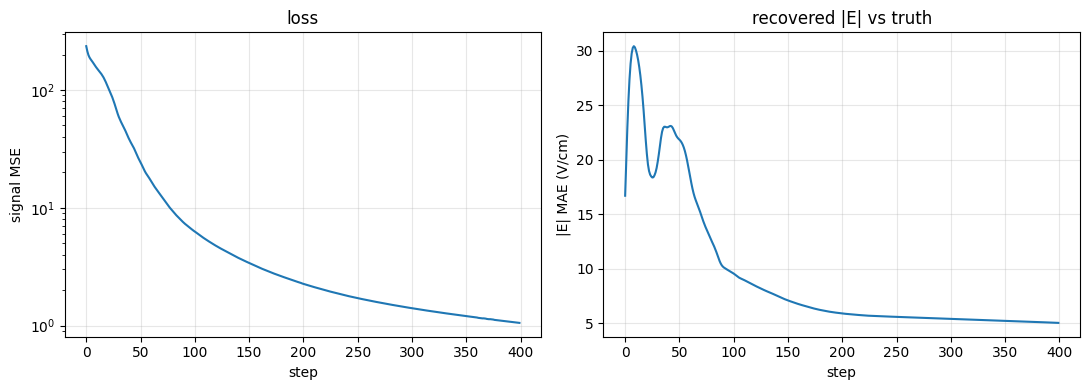

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(hist['loss']); ax[0].set(xlabel='step', ylabel='signal MSE', title='loss')
ax[0].grid(alpha=.3)
ax[1].plot(hist['emae']); ax[1].set(xlabel='step', ylabel='|E| MAE (V/cm)', title='recovered |E| vs truth')
ax[1].grid(alpha=.3)
fig.tight_layout()

## Recovered field vs truth (|E| slices)

Mid-volume z-slices of |E|: truth (loaded SIREN), recovered (fitted poly), and the residual.

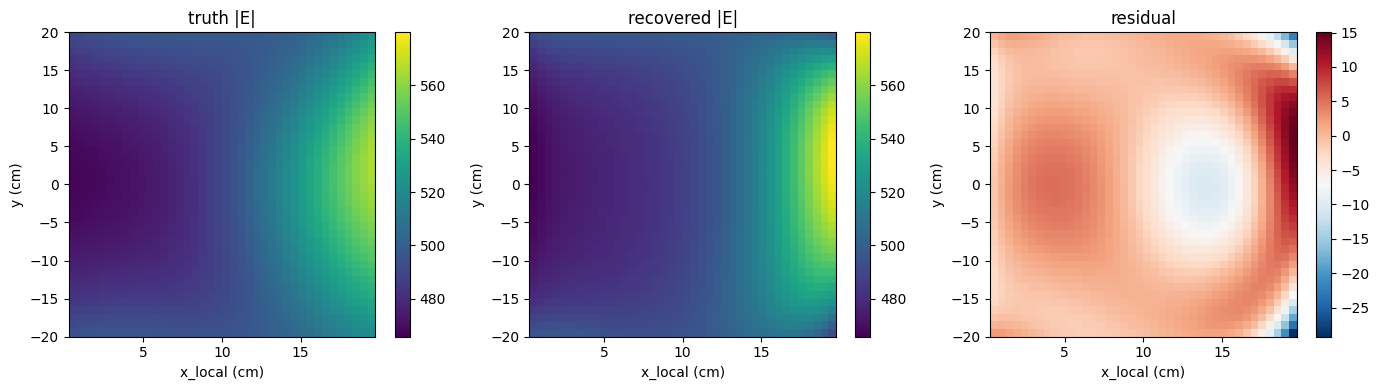

In [6]:
def emag_slice(fn):
    yy, xx = np.meshgrid(np.linspace(-19.5, 19.5, 40), np.linspace(0.5, 19.5, 40))
    pts = jnp.asarray(np.stack([xx.ravel(), yy.ravel(), np.zeros(xx.size)], -1), jnp.float32)
    return np.asarray(fn(pts)).reshape(xx.shape), xx, yy
Etrue, xx, yy = emag_slice(lambda pts: jnp.sqrt((recover_efield(
    {'weights': tp['weights'], 'biases': tp['biases']}, pts, tp['E0'], tp['v0'],
    ts['v_table'], ts['E_table'], tp['norm_offsets'], tp['norm_scales'], ts['omega_0'])**2).sum(-1)))
Erec, _, _ = emag_slice(lambda pts: jnp.sqrt((recover_efield_poly(
    coeffs, pts, rp['E0'], rp['v0'], rs['v_table'], rs['E_table'],
    rp['norm_offsets'], rp['norm_scales'], exps)**2).sum(-1)))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
vmin, vmax = float(min(Etrue.min(), Erec.min())), float(max(Etrue.max(), Erec.max()))
for a, (img, t) in zip(ax, [(Etrue, 'truth |E|'), (Erec, 'recovered |E|'), (Erec - Etrue, 'residual')]):
    m = a.pcolormesh(xx, yy, img, shading='auto',
                     **({'vmin': vmin, 'vmax': vmax} if 'residual' not in t else {'cmap': 'RdBu_r'}))
    a.set(xlabel='x_local (cm)', ylabel='y (cm)', title=t); fig.colorbar(m, ax=a)
fig.tight_layout()

## Takeaway

The distortion field is a differentiable simulator parameter: starting from a **flat** poly
field and only the cosmic wire signals, gradient descent recovers the field — the signal MSE
falls and the recovered |E| converges to the truth down to the polynomial representation floor.
This is the `distortion={'rep':'poly'}` *optimize-it-ourselves* workflow; once recovered, the
field can be `bake`d to a grid and loaded for production via `distortion='<path>'`.